<a href="https://colab.research.google.com/github/damnhuquynhvn-oss/thuchanhdeeplearning/blob/main/Lab04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from keras.datasets import mnist
import numpy as np
import keras
from keras import layers

In [2]:
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape((len(x_train),
                           np.prod(x_train.shape[1:])))

x_test = x_test.reshape((len(x_test),
                         np.prod(x_test.shape[1:])))

print(x_train.shape)
print(x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 784)
(10000, 784)


In [3]:
encoding_dim = 32

input_img = keras.Input(shape=(784,))

encoded = layers.Dense(
    encoding_dim,
    activation='relu'
)(input_img)

decoded = layers.Dense(
    784,
    activation='sigmoid'
)(encoded)

autoencoder = keras.Model(
    input_img,
    decoded
)

encoder = keras.Model(
    input_img,
    encoded
)

encoded_input = keras.Input(
    shape=(encoding_dim,)
)

decoder_layer = autoencoder.layers[-1]

decoder = keras.Model(
    encoded_input,
    decoder_layer(encoded_input)
)

In [4]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

autoencoder.fit(
    x_train,
    x_train,
    epochs=50,
    batch_size=256,
    verbose=1,
    shuffle=True,
    validation_data=(x_test, x_test)
)

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.0111 - loss: 0.2763 - val_accuracy: 0.0111 - val_loss: 0.1875
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.0102 - loss: 0.1683 - val_accuracy: 0.0078 - val_loss: 0.1516
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.0102 - loss: 0.1430 - val_accuracy: 0.0101 - val_loss: 0.1331
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.0100 - loss: 0.1280 - val_accuracy: 0.0092 - val_loss: 0.1208
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.0104 - loss: 0.1177 - val_accuracy: 0.0109 - val_loss: 0.1124
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.0104 - loss: 0.1105 - val_accuracy: 0.0110 - val_loss: 0.1062
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.0105 - loss: 0.1053 - val_accuracy: 0.0111 - val_loss: 0.1018
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.0113 - loss: 0.1015 - val_accu

In [5]:
encoded_imgs = encoder.predict(x_test)

decoded_imgs = decoder.predict(
    encoded_imgs
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


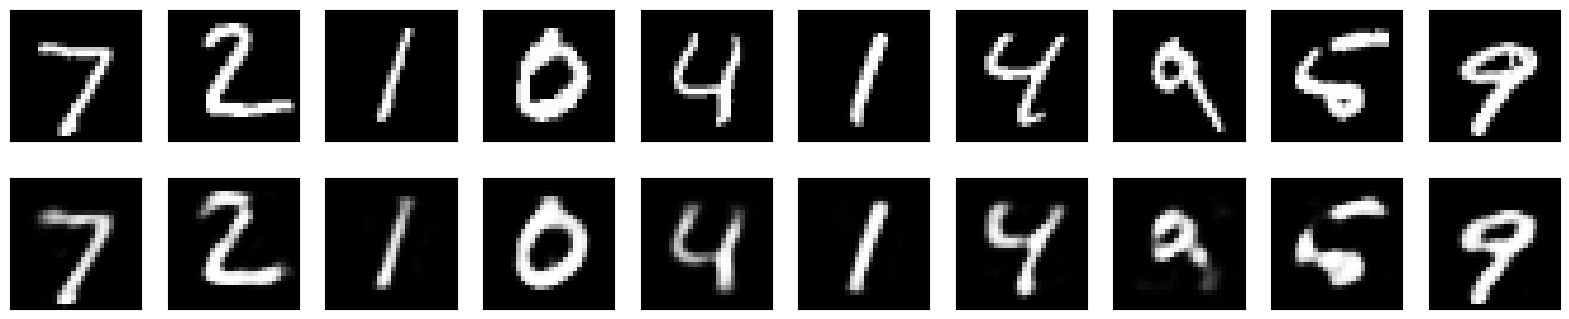

In [6]:
import matplotlib.pyplot as plt

n = 10

plt.figure(figsize=(20,4))

for i in range(n):

    ax = plt.subplot(2, n, i + 1)

    plt.imshow(
        x_test[i].reshape(28,28)
    )

    plt.gray()

    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + 1 + n)

    plt.imshow(
        decoded_imgs[i].reshape(28,28)
    )

    plt.gray()

    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

In [9]:

from keras import regularizers

encoding_dim = 32

input_img = keras.Input(shape=(784,))

encoded = layers.Dense(
    encoding_dim,
    activation='relu',
    activity_regularizer=
        regularizers.l1(10e-5)
)(input_img)

decoded = layers.Dense(
    784,
    activation='sigmoid'
)(encoded)

autoencoder = keras.Model(
    input_img,
    decoded
)

encoder = keras.Model(
    input_img,
    encoded
)

encoded_input = keras.Input(
    shape=(encoding_dim,)
)

decoder_layer = autoencoder.layers[-1]

decoder = keras.Model(
    encoded_input,
    decoder_layer(encoded_input)
)

In [10]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

autoencoder.fit(
    x_train,
    x_train,
    epochs=100,
    batch_size=256,
    verbose=1,
    shuffle=True,
    validation_data=(x_test, x_test)
)

Epoch 1/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.0142 - loss: 0.6555 - val_accuracy: 0.0161 - val_loss: 0.6155
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.0150 - loss: 0.5832 - val_accuracy: 0.0161 - val_loss: 0.5535
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.0150 - loss: 0.5274 - val_accuracy: 0.0161 - val_loss: 0.5038
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.0150 - loss: 0.4827 - val_accuracy: 0.0161 - val_loss: 0.4637
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.0150 - loss: 0.4466 - val_accuracy: 0.0161 - val_loss: 0.4314
Epoch 6/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.0150 - loss: 0.4174 - val_accuracy: 0.0161 - val_loss: 0.4050
Epoch 7/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.0151 - loss: 0.3935 - val_accuracy: 0.0161 - val_loss: 0.3834
Epoch 8/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.0150 - loss: 0.3739 - 

In [11]:
encoding_dim = 32

input_img = keras.Input(shape=(784,))

encoded = layers.Dense(
    128,
    activation='relu'
)(input_img)

encoded = layers.Dense(
    64,
    activation='relu'
)(encoded)

encoded = layers.Dense(
    encoding_dim,
    activation='relu'
)(encoded)

decoded = layers.Dense(
    784,
    activation='sigmoid'
)(encoded)

autoencoder = keras.Model(
    input_img,
    decoded
)

encoder = keras.Model(
    input_img,
    encoded
)

encoded_input = keras.Input(
    shape=(32,)
)

decoder_layer = autoencoder.layers[-1]

decoder = keras.Model(
    encoded_input,
    decoder_layer(encoded_input)
)

In [12]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

autoencoder.fit(
    x_train,
    x_train,
    epochs=50,
    batch_size=256,
    verbose=1,
    shuffle=True,
    validation_data=(x_test, x_test)
)

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.0081 - loss: 0.2653 - val_accuracy: 0.0087 - val_loss: 0.1766
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.0093 - loss: 0.1558 - val_accuracy: 0.0111 - val_loss: 0.1364
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.0100 - loss: 0.1297 - val_accuracy: 0.0089 - val_loss: 0.1214
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.0099 - loss: 0.1188 - val_accuracy: 0.0096 - val_loss: 0.1132
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.0098 - loss: 0.1119 - val_accuracy: 0.0084 - val_loss: 0.1078
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.0092 - loss: 0.1071 - val_accuracy: 0.0116 - val_loss: 0.1038
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.0095 - loss: 0.1040 - val_accuracy: 0.0106 - val_loss: 0.1016
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.0108 - loss: 0.1019 - val_acc